## Importing Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Load Dataset

In [4]:
df = pd.read_csv('census-income .csv')
df.head()
df.shape

(32561, 15)

## Understanding the Dataset


In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='object')

#### Rename the target values

In [6]:
df.rename(columns={'annual_income': 'income'}, inplace=True)

In [7]:
df.info()
df.describe()
df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [8]:
# Checking the unique values

for col in df.columns:
    print("\nColumn:", col)
    print(df[col].unique()[:20])


Column: age
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59]

Column: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

Column: fnlwgt
[ 77516  83311 215646 234721 338409 284582 160187 209642  45781 159449
 280464 141297 122272 205019 121772 245487 176756 186824  28887 292175]

Column: education
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Column: education-num
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]

Column: marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Column: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv

In [9]:
df['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [10]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [11]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [12]:
df = df.replace('?', np.nan)

In [13]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [14]:
df.isnull().sum().sum()

4262

#### Visualize the missing values

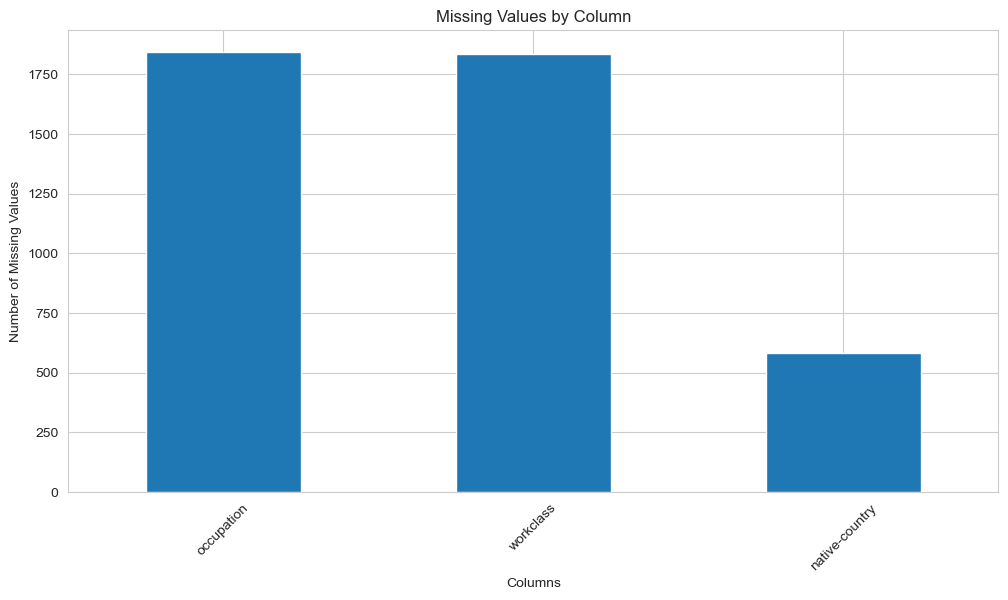

In [15]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(12, 6))
missing.sort_values(ascending=False).plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

In [16]:
df.dropna(inplace=True)

In [17]:
df.isnull().sum().sum()

0

#### Check duplicate values 

In [18]:
df.duplicated().sum()

23

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
# check again 
df.duplicated().sum()

0

## Exploratory Data Analysis

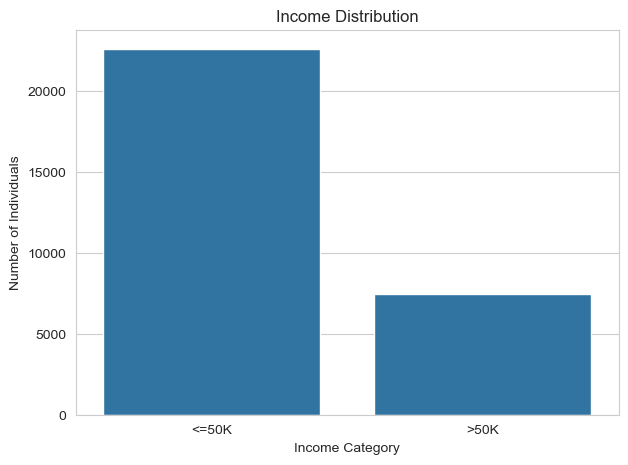

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='income')

plt.title('Income Distribution')
plt.xlabel('Income Category')
plt.ylabel('Number of Individuals')

plt.show()

In [22]:
# percentage distribution
df['income'].value_counts(normalize=True) * 100

income
<=50K    75.095391
>50K     24.904609
Name: proportion, dtype: float64

#### Age distribution


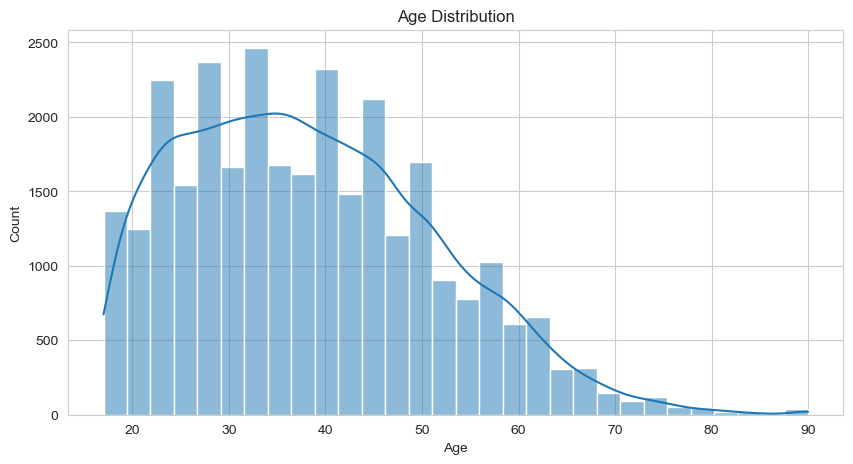

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='age', bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

#### Income vs Age 

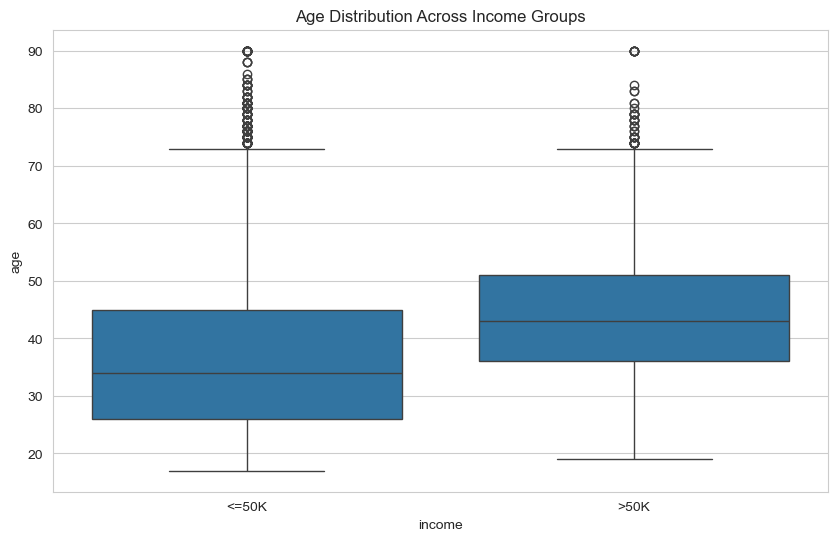

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='income', y='age')

plt.title('Age Distribution Across Income Groups')
plt.show()

#### Income vs Education

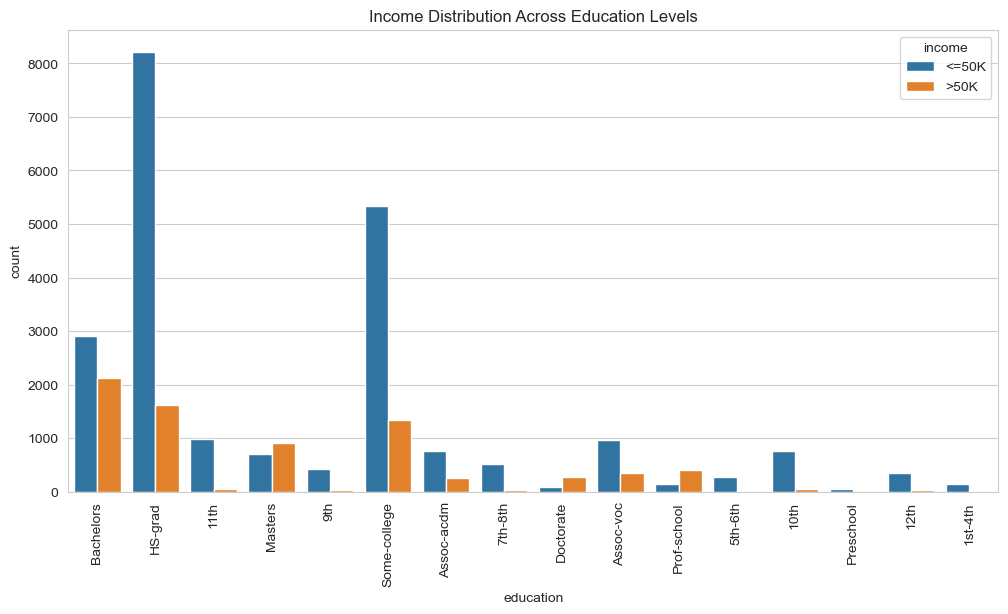

In [25]:
# This can help identify whether higher education levels are associated with higher income.
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='education',
    hue='income'
)

plt.title('Income Distribution Across Education Levels')
plt.xticks(rotation=90)
plt.show()

#### Income vs Occupation

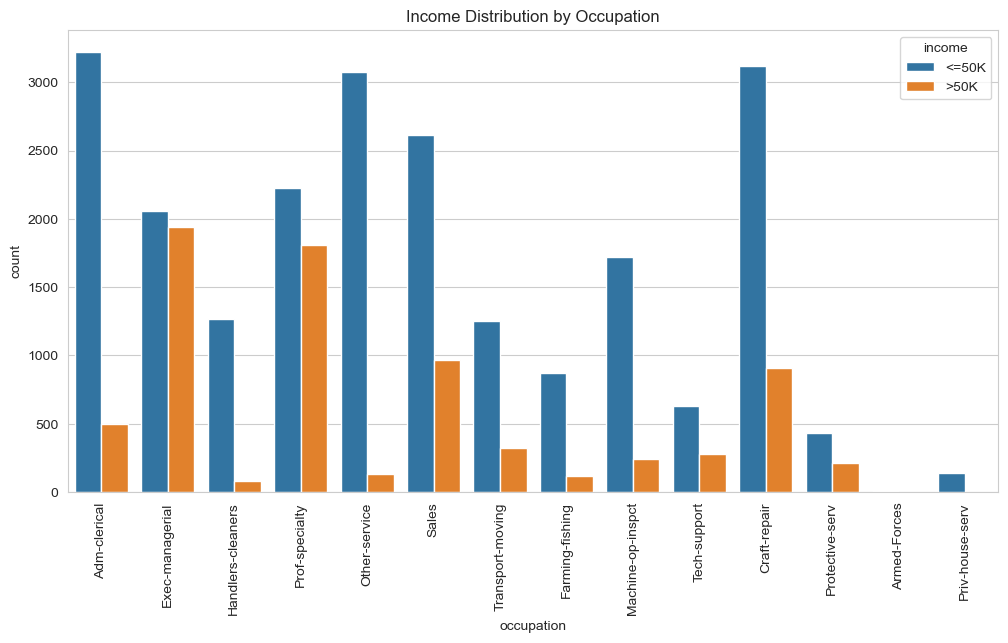

In [26]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='occupation',
    hue='income'
)

plt.title('Income Distribution by Occupation')
plt.xticks(rotation=90)
plt.show()

#### Income vs Workclass

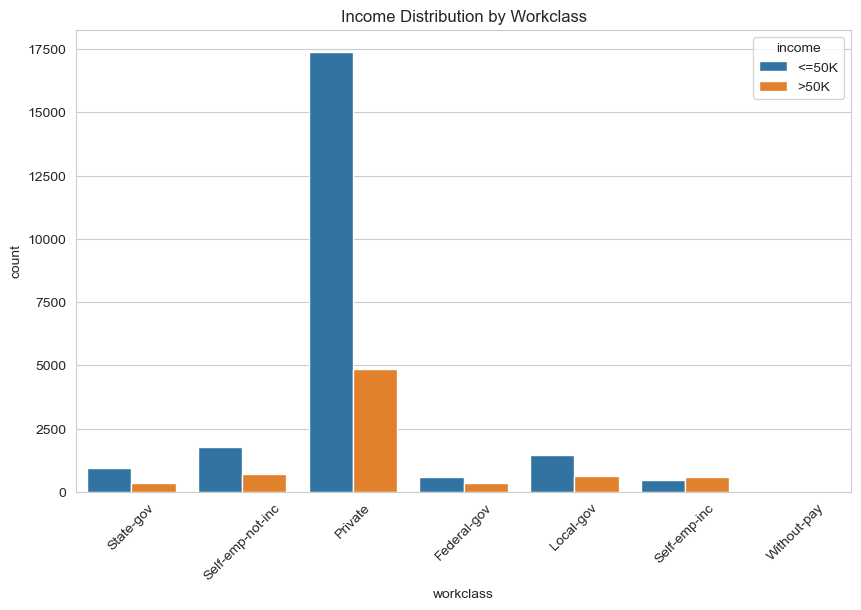

In [27]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='workclass',
    hue='income'
)

plt.title('Income Distribution by Workclass')
plt.xticks(rotation=45)

plt.show()

#### Income vs Hours per week

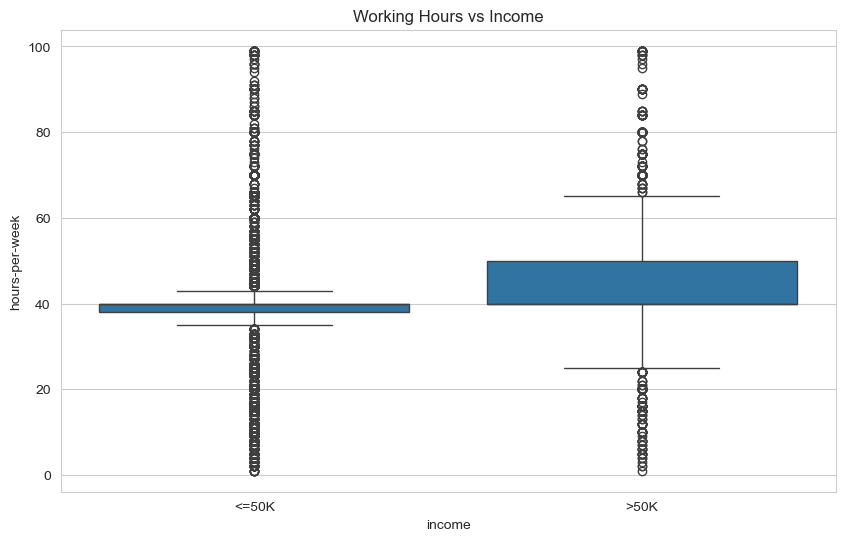

In [28]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title('Working Hours vs Income')
plt.show()

#### Capital Gain Analysis

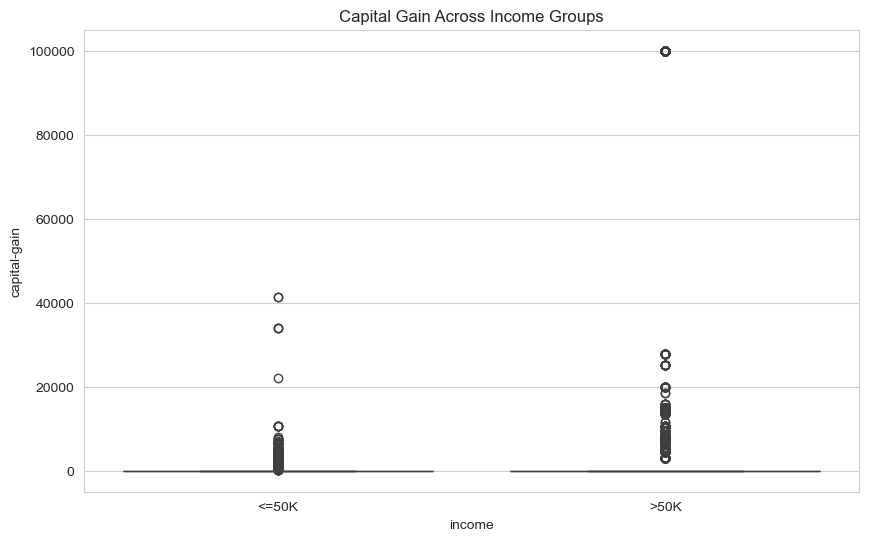

In [29]:
# Since capital-gain represents investment-related gains, this is particularly interesting
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='income',
    y='capital-gain'
)

plt.title('Capital Gain Across Income Groups')

plt.show()

In [30]:
df.groupby('income')['capital-gain'].mean()

income
<=50K     149.031989
>50K     3938.729017
Name: capital-gain, dtype: float64

#### Numerical Corelation

In [31]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [32]:
# corelation
corr = df[numeric_cols].corr()

#### Heatmap


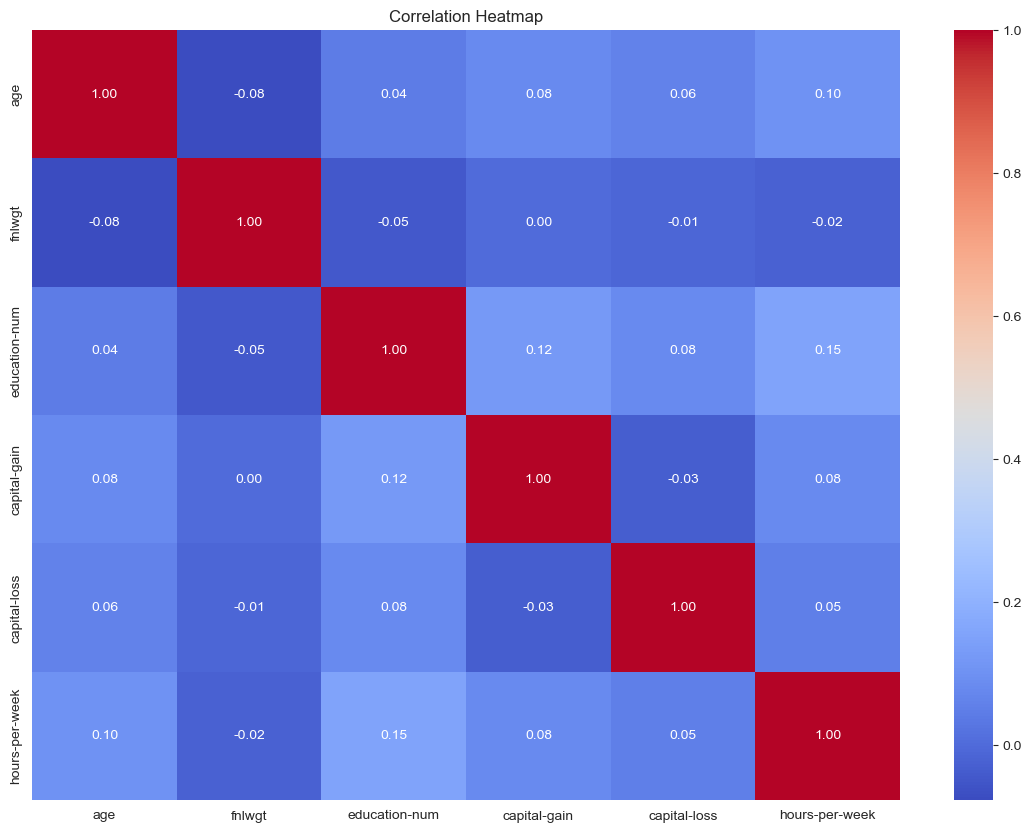

In [33]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

#### Outliers Analysis

In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns

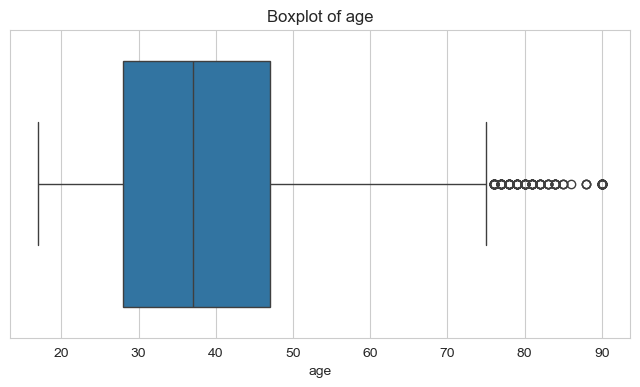

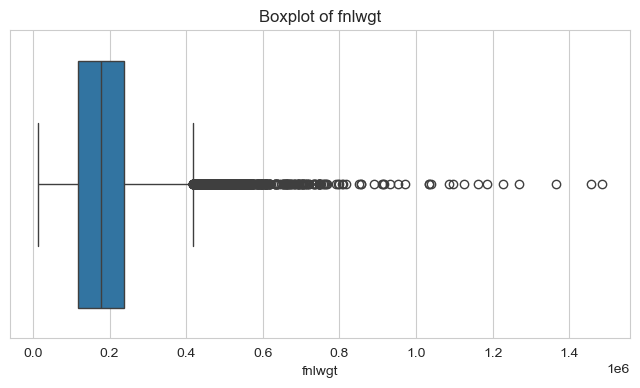

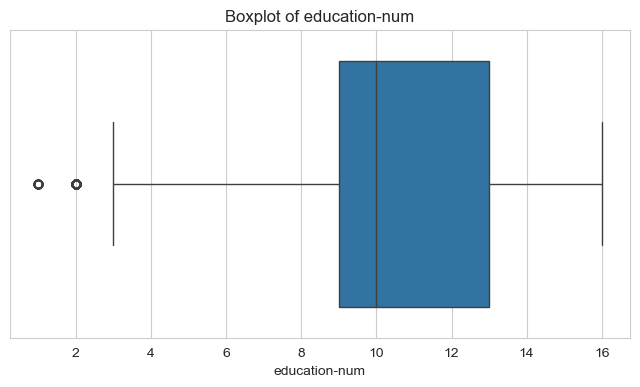

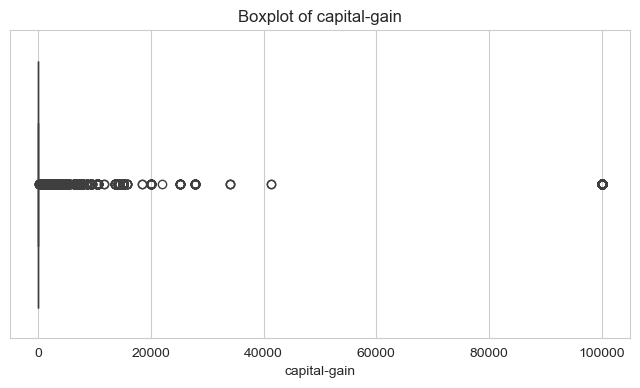

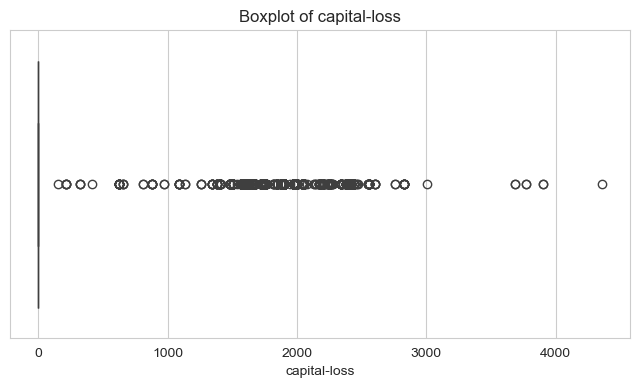

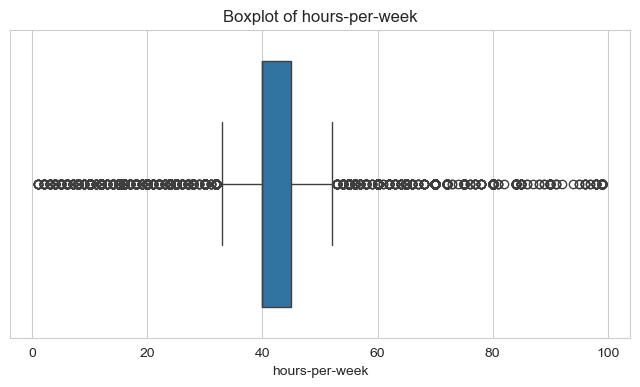

In [35]:
for col in numeric_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

#### Feature Engineering

In [36]:
df[['education', 'education-num']].head(20)

,education,education-num
0,Bachelors,13
1,Bachelors,13
2,HS-grad,9
3,11th,7
4,Bachelors,13
5,Masters,14
6,9th,5
7,HS-grad,9
8,Masters,14
9,Bachelors,13


In [37]:
df.drop('education', axis=1, inplace=True)

#### Separate X and y

In [38]:
y = df['income']

In [39]:
X = df.drop('income', axis=1)

In [40]:
X.shape

(30139, 13)

In [41]:
y.shape

(30139,)

#### Encode Target Variable

In [42]:
y = y.str.strip().map({
    '<=50K': 0,
    '>50K': 1
})

In [43]:
y.value_counts()

income
0    22633
1     7506
Name: count, dtype: int64

#### Train-Test Split

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

#### Build Preprocessing Pipeline

In [45]:
# First identify columns
categorical_cols = X.select_dtypes(include='object').columns

numerical_cols = X.select_dtypes(exclude='object').columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [46]:
# Instead of using LabelEncoder on every feature, I recommend OneHotEncoder for categorical features. 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [47]:
# Create preprocessing:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

####  Logistic Regression

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

In [49]:
lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [50]:
# logistic regression prediction
lr_pred = lr_model.predict(X_test)

#### Logistic Regression Evaluation

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [52]:
# Accuracy 
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8479318734793188


In [53]:
# Classification report 
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6790
           1       0.74      0.60      0.66      2252

    accuracy                           0.85      9042
   macro avg       0.81      0.77      0.78      9042
weighted avg       0.84      0.85      0.84      9042



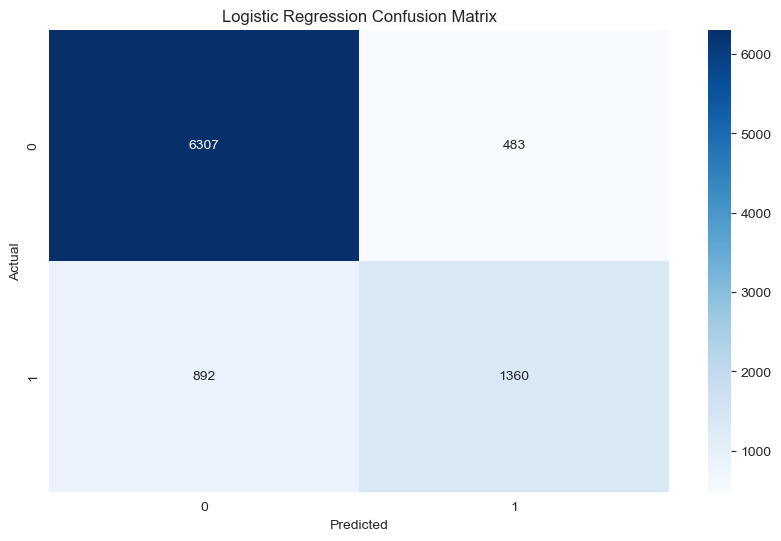

In [54]:
# Confusion matrix
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

#### Decision Tree 

In [55]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=8,
            random_state=42
        ))
    ]
)

In [56]:
# Train
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object'))])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=8, random_state=42))])

In [57]:
# Predict
dt_pred = dt_model.predict(X_test)

In [58]:
# Evaluate
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.8532404335324043
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      6790
           1       0.79      0.56      0.66      2252

    accuracy                           0.85      9042
   macro avg       0.83      0.76      0.78      9042
weighted avg       0.85      0.85      0.84      9042



#### Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [60]:
# Train
rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [61]:
# Predict 
rf_pred = rf_model.predict(X_test)

In [62]:
# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8560053085600531
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      6790
           1       0.75      0.63      0.69      2252

    accuracy                           0.86      9042
   macro avg       0.82      0.78      0.80      9042
weighted avg       0.85      0.86      0.85      9042



#### Compare Models 

In [63]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.847932,0.737927,0.603908,0.664225
1,Decision Tree,0.853240,0.788882,0.560835,0.655593
2,Random Forest,0.856005,0.749213,0.634103,0.686869


#### Visualize

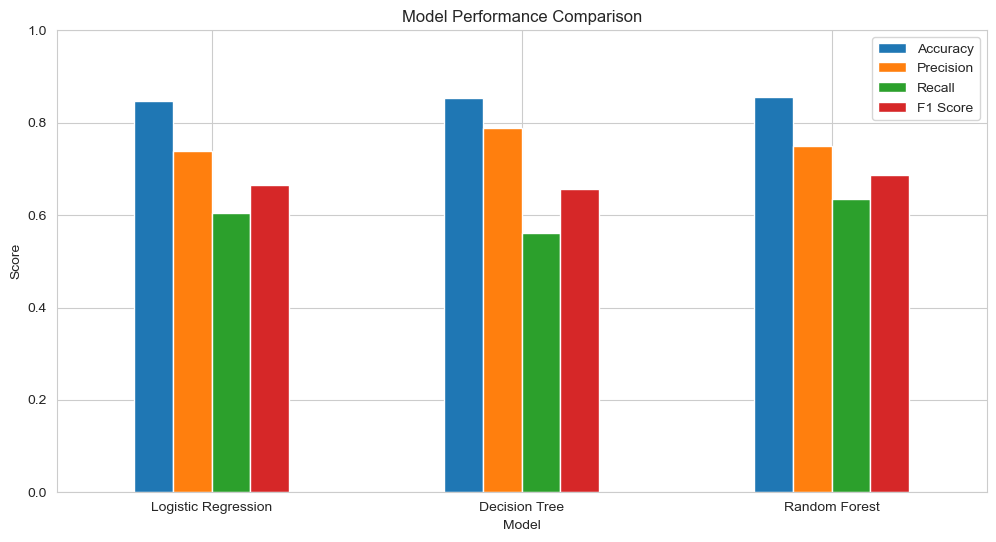

In [64]:
results.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]].plot(kind='bar', figsize=(12, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

#### ROC-AUC

In [65]:
# probabilities
lr_prob = lr_model.predict_proba(X_test)[:, 1]
dt_prob = dt_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [66]:
# Calculate
print(
    "Logistic Regression AUC:",
    roc_auc_score(y_test, lr_prob)
)

print(
    "Decision Tree AUC:",
    roc_auc_score(y_test, dt_prob)
)

print(
    "Random Forest AUC:",
    roc_auc_score(y_test, rf_prob)
)

Logistic Regression AUC: 0.9025316066621848
Decision Tree AUC: 0.8949515011366104
Random Forest AUC: 0.9044283333812917


#### Feature Importance 

In [67]:
feature_names = rf_model.named_steps[
    'preprocessor'
].get_feature_names_out()

In [68]:
importance = rf_model.named_steps[
    'classifier'
].feature_importances_

In [69]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

In [70]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [71]:
# Top 20
feature_importance.head(20)

,Feature,Importance
1,num__fnlwgt,0.163263
0,num__age,0.151189
2,num__education-num,0.112228
3,num__capital-gain,0.097939
5,num__hours-per-week,0.083903
15,cat__marital-status_Married-civ-spouse,0.064989
34,cat__relationship_Husband,0.044367
4,num__capital-loss,0.031184
17,cat__marital-status_Never-married,0.024435
23,cat__occupation_Exec-managerial,0.017276


In [72]:
# The model indicates that capital gains, education level, age, hours worked, occupation and marital status are among the important predictors of income.

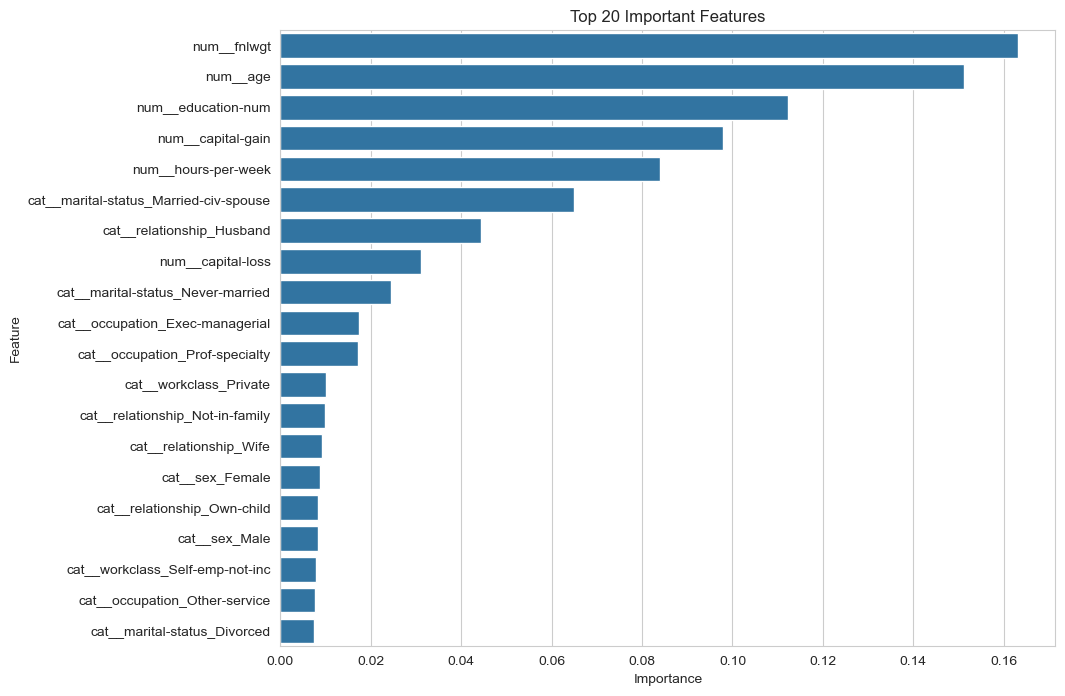

In [73]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 20 Important Features')

plt.show()

#### Hyperparameter Tuning 

In [74]:
from sklearn.model_selection import GridSearchCV

In [78]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [8, 12]
}

In [79]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [81]:
# train
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(n_estimators=200,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [8, 12],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [82]:
grid_search.best_params_

{'classifier__max_depth': 12, 'classifier__n_estimators': 200}

In [83]:
# Best model
best_model = grid_search.best_estimator_

In [84]:
# Evaluate
best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      6790
           1       0.80      0.56      0.66      2252

    accuracy                           0.86      9042
   macro avg       0.83      0.76      0.78      9042
weighted avg       0.85      0.86      0.85      9042



## Final Model 

In [85]:
final_model = best_model

In [86]:
final_pred = final_model.predict(X_test)

print("Final Model Performance")
print("-----------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, final_pred)
)

print(
    "Precision:",
    precision_score(y_test, final_pred)
)

print(
    "Recall:",
    recall_score(y_test, final_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, final_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        final_model.predict_proba(X_test)[:, 1]
    )
)

Final Model Performance
-----------------------
Accuracy: 0.8551205485512055
Precision: 0.8015364916773368
Recall: 0.5559502664298401
F1 Score: 0.6565285789197692
ROC-AUC: 0.9117579987809887


## Final Confusion Matrix

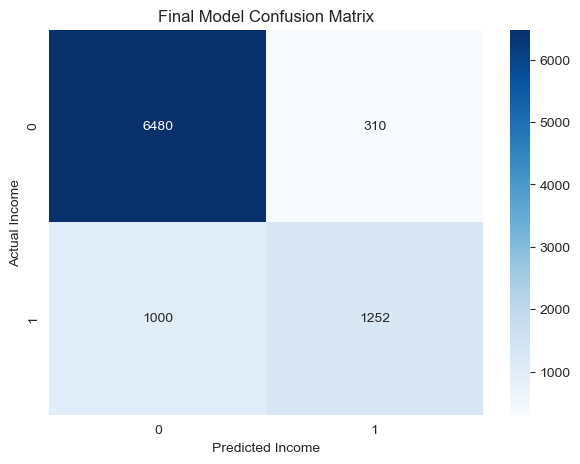

In [87]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Final Model Confusion Matrix')
plt.xlabel('Predicted Income')
plt.ylabel('Actual Income')

plt.show()